In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import recall_score, classification_report

In [47]:
oracle_64_df = pd.read_csv('classification_64.csv')
fe_stats = pd.read_csv("../Christina_results/fe_dependent_physical_v530_efficiency.csv")
o_dependent_state = pd.read_csv("../Christina_results/o_dependent_physical_v530_efficiency.csv")
naive_state = pd.read_csv("../Christina_results/naive_physical_v530_efficiency.csv")

In [48]:
oracle_64_df.head()

oracle_64_df['true_g'] = ['SLSN' if (x == 'high-z-SLSN' or x == 'low-z-SLSN') else x for x in oracle_64_df['true_g']]
oracle_64_df['pred_g'] = ['SLSN' if (x == 'high-z-SLSN' or x == 'low-z-SLSN') else x for x in oracle_64_df['pred_g']]


In [57]:
# make bins for redshift between 0 and 5, with steps of 0.1

df = fe_stats

all_status = []

for row in df.iterrows():

    # Find the left and right edges of the redshift bin
    l = row[1]['z_lo']
    r = row[1]['z_hi']

    stats = {
        'z_lo': l,
        'z_hi': r,
    }

    bin_df = oracle_64_df[(oracle_64_df['SIM_REDSHIFT_CMB'] >= l) & (oracle_64_df['SIM_REDSHIFT_CMB'] < r)]

    if len(bin_df) > 0:

        print(f"Redshift bin: {l:.1f} - {r:.1f}, Number of sources: {len(bin_df)}")
        print(np.min(bin_df['SIM_REDSHIFT_CMB']), np.max(bin_df['SIM_REDSHIFT_CMB']))

        classification_report_dict = classification_report(bin_df['true_g'], bin_df['pred_g'], output_dict=True, zero_division=np.nan)
        recall = classification_report_dict['SLSN']['recall']

        N_detects = row[1]['n_success_Detect']
        N_sigma_detects = N_detects * row[1]['sigma_Detect']

        N_success_ELAsTiCC = row[1]['n_success_ELAsTiCC']
        N_sigma_ELAsTiCC = row[1]['sigma_ELAsTiCC'] * N_success_ELAsTiCC

        N_oracle_detects = N_success_ELAsTiCC * recall
        N_sigma_oracle_detects = N_oracle_detects * row[1]['sigma_ELAsTiCC']
        
        stats['N_detects'] = N_detects
        stats['N_sigma_detects'] = N_sigma_detects
        stats['N_success_ELAsTiCC'] = N_success_ELAsTiCC
        stats['N_sigma_ELAsTiCC'] = N_sigma_ELAsTiCC
        stats['N_oracle_detects'] = N_oracle_detects
        stats['N_sigma_oracle_detects'] = N_sigma_oracle_detects

        print(f"Recall: {classification_report_dict['SLSN']['recall']:.4f}")

    all_status.append(stats)

#plt.legend()

Redshift bin: 0.1 - 0.2, Number of sources: 28179
0.1000010892748832 0.1999977231025695
Recall: 0.6842
Redshift bin: 0.2 - 0.3, Number of sources: 47498
0.2000009417533874 0.2999977469444275
Recall: 0.7470
Redshift bin: 0.3 - 0.4, Number of sources: 54839
0.3000001609325409 0.399996668100357
Recall: 0.7850
Redshift bin: 0.4 - 0.5, Number of sources: 52367
0.4000029265880584 0.4999969005584717
Recall: 0.8539
Redshift bin: 0.5 - 0.6, Number of sources: 44778
0.5000002384185791 0.5999979972839355
Recall: 0.8532
Redshift bin: 0.6 - 0.7, Number of sources: 36889
0.6000030040740967 0.6999964714050293
Recall: 0.8575
Redshift bin: 0.7 - 0.8, Number of sources: 28377
0.7000018954277039 0.799995481967926
Recall: 0.8889
Redshift bin: 0.8 - 0.9, Number of sources: 20144
0.800001323223114 0.899997353553772
Recall: 0.8918
Redshift bin: 0.9 - 1.0, Number of sources: 14388
0.9000028967857361 0.9999791979789734
Recall: 0.8795
Redshift bin: 1.0 - 1.1, Number of sources: 10539
1.000012993812561 1.0999848

Text(0.5, 1.0, 'Number of SLSNe detected by different methods')

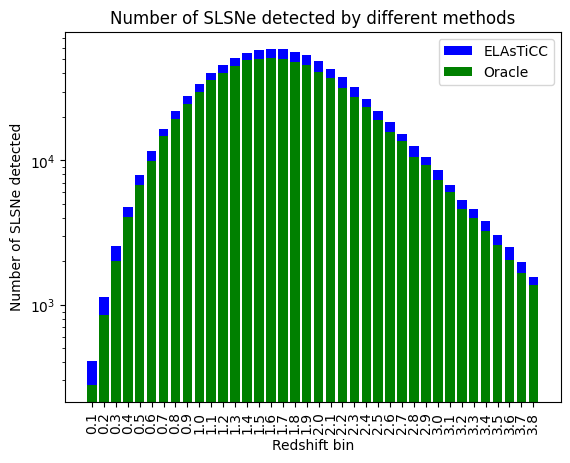

In [67]:
for s in all_status:

    if 'N_detects' not in s:
        continue

    # Make bars for each of the three detection methods
    # plt.bar(f"{s['z_lo']:.1f}", s['N_detects'], label='Detect', color='gray', zorder=0)
    plt.bar(f"{s['z_lo']:.1f}", s['N_success_ELAsTiCC'], label='ELAsTiCC', color='blue', zorder=1)
    plt.bar(f"{s['z_lo']:.1f}", s['N_oracle_detects'], label='Oracle', color='green', zorder=2)

plt.xlabel('Redshift bin')
plt.ylabel('Number of SLSNe detected')

# flip the x-ticks to be vertical
plt.xticks(rotation=90)

# remove duplicate labels in the legend
plt.legend()
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.yscale('log')

plt.title('Number of SLSNe detected by different methods')